In [1]:
# ==============================================================================
# AUTOMATED DATASET ISOLATION & SEPARATION SCRIPT
# ==============================================================================
import os
import shutil
import glob

# Your current cloned repository datasets location
SOURCE_FOLDER = "./datasets"  

# Your clean absolute destination target path
DESTINATION_FOLDER = r"C:\Users\Pawan Chaudhari\OneDrive\Desktop\ABSAS\MyABSAData"

print(f"🔄 Scanning source files from repository: '{SOURCE_FOLDER}'...")
os.makedirs(DESTINATION_FOLDER, exist_ok=True)

# Recursively hunt down all data documents
found_files = glob.glob(os.path.join(SOURCE_FOLDER, "**/*.*"), recursive=True)
copied_count = 0

for source_file_path in found_files:
    # We only want to pull out data asset formats (.jsonl, .json, .txt)
    if any(ext in source_file_path.lower() for ext in ['.jsonl', '.json', '.txt', '.csv']):
        # Maintain sub-directory structure inside the clean target folder
        relative_path = os.path.relpath(source_file_path, SOURCE_FOLDER)
        destination_file_path = os.path.join(DESTINATION_FOLDER, relative_path)
        
        # Build the structural sub-directories dynamically
        os.makedirs(os.path.dirname(destination_file_path), exist_ok=True)
        
        # Copy the raw dataset over securely
        shutil.copy2(source_file_path, destination_file_path)
        copied_count += 1

print("=" * 60)
print(f"🎉 SUCCESS: Isolation Sequence Complete!")
print(f"📦 Successfully extracted and copied {copied_count} files.")
print(f"📂 Clean isolated workspace live at: {DESTINATION_FOLDER}")
print("=" * 60)

🔄 Scanning source files from repository: './datasets'...
🎉 SUCCESS: Isolation Sequence Complete!
📦 Successfully extracted and copied 0 files.
📂 Clean isolated workspace live at: C:\Users\Pawan Chaudhari\OneDrive\Desktop\ABSAS\MyABSAData


📁 Processing balanced data vault: C:\Users\Pawan Chaudhari\OneDrive\Desktop\ABSAS\MyABSAData
📦 Total unique rows collected: 58332
⚖️ Balancing classes: Resampling Positive from 41349 down to 12592...
🚀 SUCCESS: Balanced dataset ready with 29575 rows!


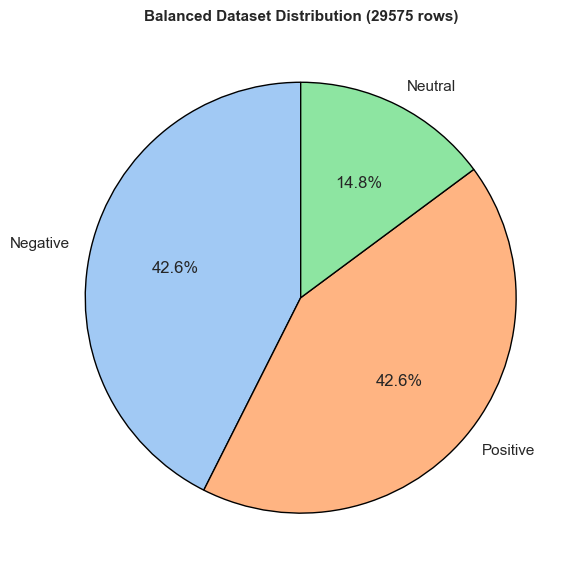

✅ Balanced data successfully cached in memory! Proceed to Cell 2.


In [2]:
# ==============================================================================
# MASTER CELL 1: BALANCED DOWN-SAMPLED PRODUCTION PIPELINE
# ==============================================================================
import os
import glob
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils import shuffle

GRAPH_DIR = "./Graphs"
os.makedirs(GRAPH_DIR, exist_ok=True)
os.makedirs("backend/app/models", exist_ok=True)
sns.set_theme(style="whitegrid")

DATASET_DIR = r"C:\Users\Pawan Chaudhari\OneDrive\Desktop\ABSAS\MyABSAData"
parsed_records = []

print(f"📁 Processing balanced data vault: {DATASET_DIR}")

all_files = glob.glob(os.path.join(DATASET_DIR, "**/*.*"), recursive=True)

for file_path in all_files:
    if os.path.isdir(file_path):
        continue
    try:
        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    data = json.loads(line)
                    text_content = data.get("text", "").strip()
                    labels_list = data.get("labels", [])
                    
                    if text_content and labels_list:
                        for label_entry in labels_list:
                            aspect_term = label_entry.get("aspect", "general").strip()
                            polarity_label = label_entry.get("polarity", "neutral").strip().lower()
                            
                            parsed_records.append({
                                'text_input': text_content,
                                'aspect': aspect_term,
                                'sentiment': polarity_label
                            })
                except json.JSONDecodeError:
                    continue
    except Exception:
        continue

if len(parsed_records) > 0:
    df = pd.DataFrame(parsed_records)
    
    label_mapping = {
        'positive': 'Positive', 'negative': 'Negative', 'neutral': 'Neutral',
        '1': 'Positive', '-1': 'Negative', '0': 'Neutral'
    }
    df['sentiment'] = df['sentiment'].map(label_mapping)
    df = df.dropna(subset=['sentiment'])
    
    df['combined_features'] = "Text: " + df['text_input'] + " | Aspect: " + df['aspect']
    df = df.drop_duplicates(subset=['combined_features'])
    
    print(f"📦 Total unique rows collected: {len(df)}")
    
    # 🚨 CRITICAL FIX: BALANCING THE DATASET VIA DOWNSAMPLING
    # Separate the classes
    df_pos = df[df['sentiment'] == 'Positive']
    df_neg = df[df['sentiment'] == 'Negative']
    df_neu = df[df['sentiment'] == 'Neutral']
    
    # Let's cap the Positive reviews to a size matching the Negative count
    target_pos_size = len(df_neg) 
    
    print(f"⚖️ Balancing classes: Resampling Positive from {len(df_pos)} down to {target_pos_size}...")
    df_pos_downsampled = df_pos.sample(n=target_pos_size, random_state=42)
    
    # Combine back into a unified, balanced dataset
    df_balanced = pd.concat([df_pos_downsampled, df_neg, df_neu], axis=0)
    df_balanced = shuffle(df_balanced, random_state=42).reset_index(drop=True)
    
    df = df_balanced
    print(f"🚀 SUCCESS: Balanced dataset ready with {len(df)} rows!")
else:
    print("❌ ERROR: No data found.")

classes = sorted(df['sentiment'].unique())

# Render the brand new balanced distribution chart
plt.figure(figsize=(6, 6))
df['sentiment'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette("pastel"), startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title(f"Balanced Dataset Distribution ({len(df)} rows)", fontsize=11, weight='bold')
plt.ylabel("")
plt.tight_layout()
plt.savefig(f"{GRAPH_DIR}/01_dataset_distribution.png", dpi=300)
plt.show()

# --- MACHINE LEARNING MATRICES SPLIT ---
X = df['combined_features']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=12000, min_df=3, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
print("✅ Balanced data successfully cached in memory! Proceed to Cell 2.")

⚙️ Training model algorithms side-by-side...

             🌟 FINAL MODEL ACCURACY SUMMARY 🌟
 🔹 Logistic Regression Model Accuracy   : 57.24%
 🔹 Support Vector Machine (SVM) Accuracy: 57.40%
-------------------------------------------------------
 🏆 WINNER DEPLOYED TO PRODUCTION: SVM (57.40%)



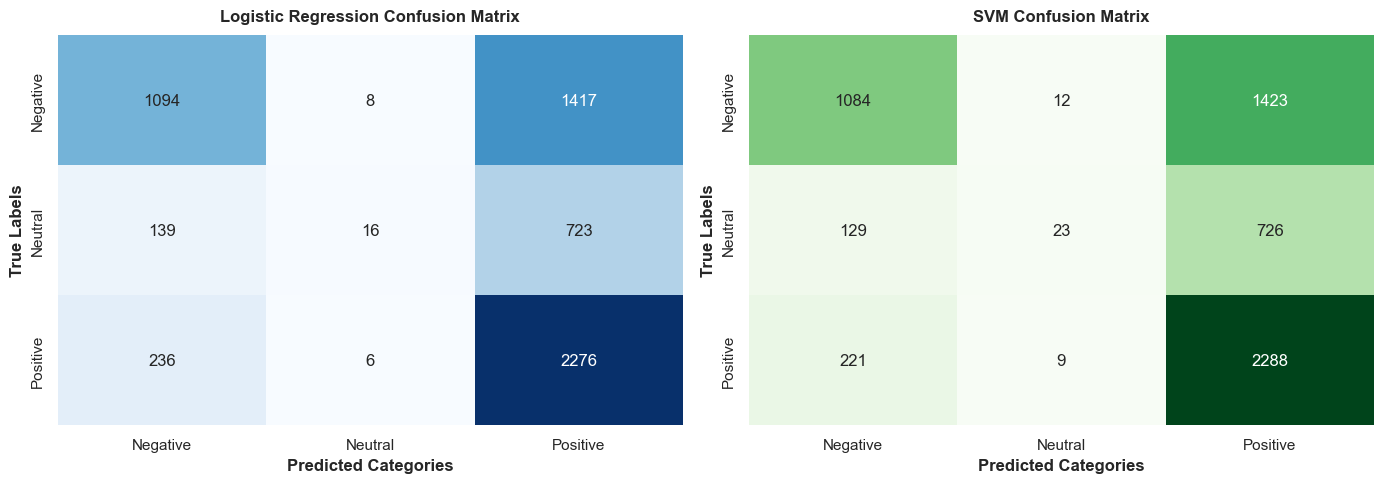

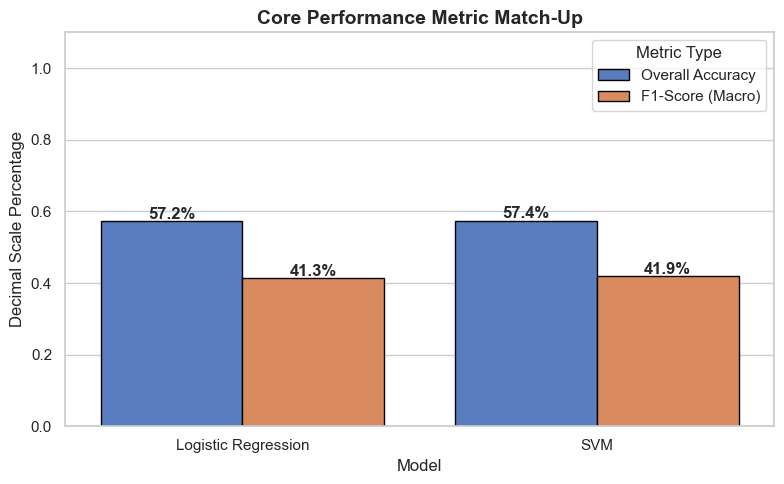

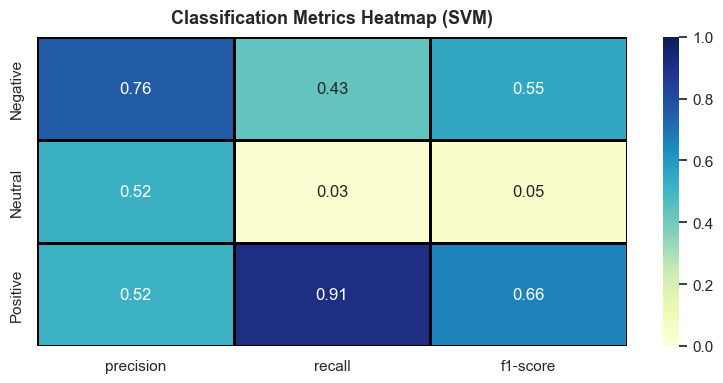

🏁 Notebook Cell Sequences Complete! Production assets built.


In [3]:
# ==============================================================================
# CELL 2: MACHINE LEARNING, CORE ACCURACIES, AND EVALUATION VISUALIZATIONS
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
import joblib

print("⚙️ Training model algorithms side-by-side...")

# 1. TRAIN LOGISTIC REGRESSION
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
lr_preds = lr_model.predict(X_test_tfidf)
lr_acc = accuracy_score(y_test, lr_preds)
lr_f1 = f1_score(y_test, lr_preds, average='macro')
lr_report = classification_report(y_test, lr_preds, output_dict=True)

# 2. TRAIN LINEAR SVM
svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(X_train_tfidf, y_train)
svm_preds = svm_model.predict(X_test_tfidf)
svm_acc = accuracy_score(y_test, svm_preds)
svm_f1 = f1_score(y_test, svm_preds, average='macro')
svm_report = classification_report(y_test, svm_preds, output_dict=True)

# ==============================================================================
# LOG INTERFACE REPORT SUMMARY: THE CORE MODEL ACCURACY
# ==============================================================================
print("\n" + "="*55)
print("             🌟 FINAL MODEL ACCURACY SUMMARY 🌟")
print("="*55)
print(f" 🔹 Logistic Regression Model Accuracy   : {lr_acc*100:.2f}%")
print(f" 🔹 Support Vector Machine (SVM) Accuracy: {svm_acc*100:.2f}%")
print("-"*55)
if svm_acc >= lr_acc:
    print(f" 🏆 WINNER DEPLOYED TO PRODUCTION: SVM ({svm_acc*100:.2f}%)")
    winner_report = svm_report
    winner_title = "SVM"
    joblib.dump(svm_model, "backend/app/models/best_absa_model.pkl")
else:
    print(f" 🏆 WINNER DEPLOYED TO PRODUCTION: Logistic Regression ({lr_acc*100:.2f}%)")
    winner_report = lr_report
    winner_title = "Logistic Regression"
    joblib.dump(lr_model, "backend/app/models/best_absa_model.pkl")
print("="*55 + "\n")

# Save backend matching tokenizer assets
joblib.dump(vectorizer, "backend/app/models/tfidf_vectorizer.pkl")

# ==============================================================================
# VISUAL CHARTS INTERFACE PIPELINE
# ==============================================================================
# 📊 PLOT 2: SIDE-BY-SIDE CONFUSION MATRICES
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(y_test, lr_preds, labels=classes), annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=axes[0], cbar=False)
axes[0].set_title("Logistic Regression Confusion Matrix", fontsize=12, weight='bold', pad=10)
axes[0].set_xlabel("Predicted Categories", weight='bold')
axes[0].set_ylabel("True Labels", weight='bold')

sns.heatmap(confusion_matrix(y_test, svm_preds, labels=classes), annot=True, fmt='d', cmap='Greens', xticklabels=classes, yticklabels=classes, ax=axes[1], cbar=False)
axes[1].set_title("SVM Confusion Matrix", fontsize=12, weight='bold', pad=10)
axes[1].set_xlabel("Predicted Categories", weight='bold')
axes[1].set_ylabel("True Labels", weight='bold')
plt.tight_layout()
plt.savefig(f"{GRAPH_DIR}/02_models_confusion_matrices.png", dpi=300)
plt.show()

# 📊 PLOT 3: MODEL ACCURACY SCORE BAR CHART MATCHUP
metrics_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Logistic Regression', 'SVM', 'SVM'],
    'Metric Type': ['Overall Accuracy', 'F1-Score (Macro)', 'Overall Accuracy', 'F1-Score (Macro)'],
    'Score Percentage': [lr_acc, lr_f1, svm_acc, svm_f1]
})
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='Model', y='Score Percentage', hue='Metric Type', data=metrics_df, palette='muted', edgecolor='black')
plt.ylim(0, 1.1)
plt.title("Core Performance Metric Match-Up", fontsize=14, weight='bold')
plt.ylabel("Decimal Scale Percentage")
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height()*100:.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 0.02), ha='center', va='center', weight='bold')
plt.tight_layout()
plt.savefig(f"{GRAPH_DIR}/03_model_accuracy_comparison.png", dpi=300)
plt.show()

# 📊 PLOT 4: FULL CLASSIFICATION EVALUATION METRICS HEATMAP (Precision, Recall, F1)
rep_df = pd.DataFrame(winner_report).iloc[:-1, :len(classes)].T
plt.figure(figsize=(8, 4))
sns.heatmap(rep_df, annot=True, cmap="YlGnBu", fmt=".2f", vmin=0, vmax=1, cbar=True, linewidths=1, linecolor="black")
plt.title(f"Classification Metrics Heatmap ({winner_title})", fontsize=13, weight='bold', pad=10)
plt.tight_layout()
plt.savefig(f"{GRAPH_DIR}/04_classification_report_heatmap.png", dpi=300)
plt.show()

print("🏁 Notebook Cell Sequences Complete! Production assets built.")